<a href="https://colab.research.google.com/github/yashendrakumar789-sketch/Matrix-Rain-Effect-/blob/main/E_Commerce_Consumer_Purchase_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **E-Commerce Consumer Purchase Prediction Analysis\**

#Important Libraries


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()


df = pd.read_csv('ecom_purchase_prediction4.csv')

Saving ecom_purchase_prediction4.csv to ecom_purchase_prediction4.csv


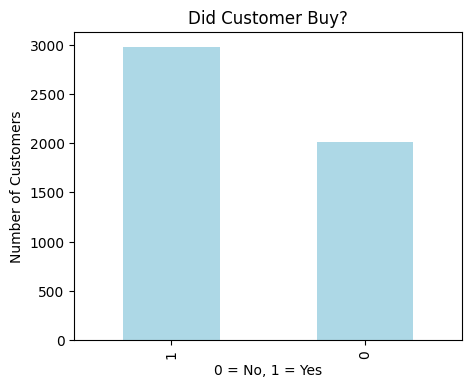

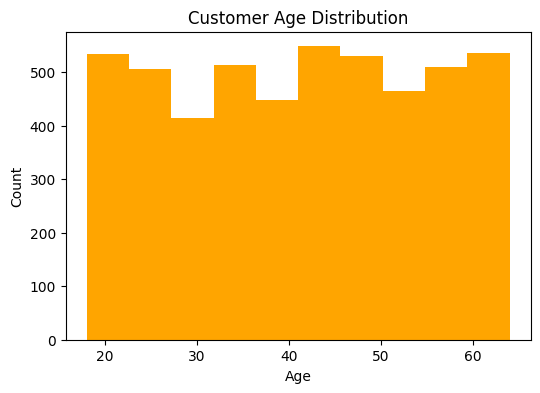

In [ ]:

plt.figure(figsize=(5,4))
df['Purchased'].value_counts().plot(kind='bar', color='lightblue')
plt.title('Did Customer Buy?')
plt.xlabel('0 = No, 1 = Yes')
plt.ylabel('Number of Customers')
plt.show()


plt.figure(figsize=(6,4))
plt.hist(df['Age'], color='orange')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [ ]:

X = df.drop('Purchased', axis=1)
y = df['Purchased']


####Train and Test split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data splitted!")
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Data splitted!
Train size: 4000
Test size: 1000


###MODEL 1 -Random Forest

In [ ]:
print("--- Training Model 1: Random Forest ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {round(rf_accuracy * 100, 2)} %\n")


--- Training Model 1: Random Forest ---
Random Forest Accuracy: 86.6 %



###Model 2-Decision Tree

In [ ]:
print("--- Training Model 2: Decision Tree ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {round(dt_accuracy * 100, 2)} %\n")

--- Training Model 2: Decision Tree ---
Decision Tree Accuracy: 82.6 %



###Model 3- logistic regression

In [ ]:
print("--- Training Model 3: Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {round(lr_accuracy * 100, 2)} %\n")

--- Training Model 3: Logistic Regression ---
Logistic Regression Accuracy: 81.4 %



In [ ]:
print("="*55)
print("                 FINAL ACCURACY SUMMARY")
print("="*55)
print(f"Random Forest        : {round(rf_accuracy * 100, 2)} %")
print(f"Decision Tree        : {round(dt_accuracy * 100, 2)} %")
print(f"Logistic Regression  : {round(lr_accuracy * 100, 2)} %")
print("="*55)

                 FINAL ACCURACY SUMMARY
Random Forest        : 86.6 %
Decision Tree        : 82.6 %
Logistic Regression  : 81.4 %


#GRAPHS


In [ ]:
new_customer = pd.DataFrame({
    'Age': [30],
    'Session_Duration_Min': [12],
    'Pages_Viewed': [20],
    'Items_In_Cart': [3],
    'Days_Since_Last_Visit': [10],
    'Discount_Used': [1]
})

rf_pred_new = rf_model.predict(new_customer)[0]
print("Customer Details → Age:30, Session:45min, Pages:12, Cart:3, Days since last:10, Discount:Yes")
print("Prediction →", "WILL PURCHASE" if rf_pred_new == 1 else "WILL NOT PURCHASE")

lr_pred_new = lr_model.predict(new_customer)[0]
print("Customer Details → Age:30, Session:45min, Pages:12, Cart:3, Days since last:10, Discount:Yes")
print("Prediction →", "WILL PURCHASE" if lr_pred_new == 1 else "WILL NOT PURCHASE")

dt_pred_new = dt_model.predict(new_customer)[0]
print("Customer Details → Age:30, Session:45min, Pages:12, Cart:3, Days since last:10, Discount:Yes")
print("Prediction →", "WILL PURCHASE" if dt_pred_new == 1 else "WILL NOT PURCHASE")



Customer Details → Age:30, Session:45min, Pages:12, Cart:3, Days since last:10, Discount:Yes
Prediction → WILL PURCHASE
Customer Details → Age:30, Session:45min, Pages:12, Cart:3, Days since last:10, Discount:Yes
Prediction → WILL PURCHASE
Customer Details → Age:30, Session:45min, Pages:12, Cart:3, Days since last:10, Discount:Yes
Prediction → WILL PURCHASE


#-----------------------------------DEPLOYMENT----------------------------------


##**Model Import**


In [ ]:
import joblib

# Assuming you have trained rf, dt, lr models
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(dt_model, 'dt_model.pkl')
joblib.dump(lr_model, 'lr_model.pkl')

print("✅ All 3 models saved successfully!")

✅ All 3 models saved successfully!
